# Set up

## Import packages

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Set up `Session`

In [2]:
# Create session
session = cm.Session(
    name = 'feed_dist_example',
    data_path = '../data'
)

# Add scenarios
session.add_scenario(
    name = 'base_feed',
    scenario_workbooks = 'fix_default_feeddist',
    years = '2020'
)

session.add_scenario(
    name = 'base_geo',
    scenario_workbooks = None,
    years = '2020'
)

A scenario with the name 'base_feed' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base_geo' already exists use .update_scenario() or .remove_scenario() instead.


# Run model

## Instantiate modules

In [3]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    regions = regions
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt_feed = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt'),
    type = 'FeedDist'
)
feed_mgmt_geo = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt'),
    type = 'GeoDist'
)

# Instantiate distributor
feed_dist = cm.FeedDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt_feed,
    par = cm.ParameterRetriever('GeoDistributor')
)
geo_dist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt_geo,
    par = cm.ParameterRetriever('GeoDistributor')
)

## Run calculations

In [159]:
%%time
scn = 'base_feed'
year = '2020'

cm.ParameterRetriever.update_all_parameter_values(
    **session[scn],
    year = year
)

# Get region attributes
regions.calculate()

# Calculate food demand
demand.calculate()

# Calculate crops
crops.calculate()

# Calculate herds
for h in herds:
    h.calculate()

if 'feed' in scn:
    dist = feed_dist
    dist.make(use_cons=[1,2,3,4,5,6,7,   11,12,13], scale_power=0.4, verbose=True)
    dist.solve(verbose=True)
    feed_mgmt_feed.calculate()
else:
    dist = geo_dist
    feed_mgmt_geo.calculate()
    dist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.4, verbose=True)
    dist.solve(verbose=True)
    feed_mgmt_geo.calculate2()

# Store results
session.store(
    scn, year,
    demand, regions, crops, herds, dist
)


c:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\retriever.py:152: UserWarning: 
-----------------------------------------------------------------------------
Some filter values included in data were not available in relation_tables.xlsx.
Missing for 'feed': 'minerals', 'maize gluten meal', 'rapeseed cake'
Missing for 'by_prod': 'maize gluten meal', 'cream', 'fish meal', 'palm kernel expeller', 'soybean protein concentrate', 'luzern meal', 'soybean meal'
------------------------------------------------------------------------------
  warnings.warn(f"""


[PBV, fat, AAT, ME, DM] [PBV, fat, AAT, ME, DM] [PBV, fat, AAT, ME, DM] [PBV, fat, AAT, ME, DM] [PBV, fat, AAT, ME, DM] [PBV, fat, AAT, ME, DM] [ME] [ME] [ME] [ME] [ME] [ME] [ME] [ME] [NE] [NE] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [12:16:31][FeedDistributor.make] Getting x0 and making indexes ... 2.6s
[12:16:34][FeedDistributor.make] Creating demand vector ... 0.0s
[12:16:34][FeedDistributor.make] Calculating scaling factors ... 0.0s
[12:16:34][FeedDistributor.make] Making objective O1 ... 0.1s
[12:16:34][FeedDistributor.make] Making constraint C1... 0.6s
[12:16:35][FeedDistributor.make] Making constraint C2... 0.3s
[12:16:35][FeedDistributor.make] Making constraint C3... 0.2s
[12:16:35][FeedDistributor.make] Making constraint C4... 0.2s
[12:16:35][FeedDistributor.make] Making constraint C5... 0.3s
[12:16:36][FeedDistributor.make] Making constraint C6... 0.4s
[12:16:36][FeedDistributor.make] Making constraint C11... 3.0s
[12:16:39][FeedDistributor.make] Making co

c:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\mgmt_modules\feed_mgmt\feed_mgmt.py:103: UserWarning: FeedMgmt: Specified domestic shares for 'by_prod' will have no effect! 
For by-products, imports are handled in the ByProductMgmt module and for crop residues, imports are not allowed.
  warnings.warn(
c:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\retriever.py:364: UserWarning: NaNs returned! No value for 'feed_composition' found in 'FeedMgmt'.xlsx for some of the supplied filters (n=318): 
----------
f_species = poultry
f_breed = broiler
f_region = 1011
f_prod_system = conventional
f_animal = breeding hens
f_feed = rapeseed cake
f_feed_par = AME
----------
f_species = poultry
f_breed = broiler
f_region = 1011
f_prod_system = conventional
f_animal = breeding roosters
f_feed = rapeseed cake
f_feed_par = AME
----------
f_species = poultry
f_breed = broiler
f_region = 1011
f_prod_system = conventional
f_animal = broilers
f_feed = rapeseed cake
f_feed_par = AM

Writing outputs to 'c:\Users\jnka0003\Git repos\CIBUSmod\data\output\feed_dist_example.sqlite'


c:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1551: UserWarning: Negative values of down to -304492265.9151561 */year in AnimalHerd.feed_req_min.
  warnings.warn(f'Negative values of down to {data.min().min()} {module.data_attr[attr]["unit"]} in {module_name}.{attr}.')


Outputs stored!
CPU times: total: 4min 28s
Wall time: 2min 9s


In [151]:
def get_rat_comp(h, par, per_dm=True):
    feed_mgmt_feed.par.clear()
    feed_mgmt_feed.par.set(species=h.species, breed=h.breed)
    feed_DM = h.data_attr.get("feed.consumption")
    ration_DM = feed_DM.T.groupby(["prod_system", "animal"]).sum().T

    res = (
        (
            feed_mgmt_feed.par.get_from_frame(
                "feed_composition", feed_DM, feed_par=par
            )
            * feed_DM
        )
        .T.groupby(["prod_system", "animal"])
        .sum()
        .T
        / (ration_DM.replace({0: np.nan}) if per_dm else 1)  # To avoid div by 0 error
    )

    return res

In [158]:
h = herds.iloc[5]
par = 'AAT'

print(h.species,h.prod_system,h.breed,h.sub_system, sep=', ')
print(par)

###########################################

(get_rat_comp(h, 'AAT')/get_rat_comp(h, 'ME')).min()

(get_rat_comp(h, 'PBV', per_dm=False) / h.data_attr.get('heads') / 365.25)

cattle, organic, dairy, ley based
AAT


prod_system   conventional                                           \
animal      breeding bulls bulls calves, bull calves, for slaughter   
region                                                                
1011                   NaN   NaN          NaN                   NaN   
111                    NaN   NaN          NaN                   NaN   
1111                   NaN   NaN          NaN                   NaN   
1112                   NaN   NaN          NaN                   NaN   
112                    NaN   NaN          NaN                   NaN   
...                    ...   ...          ...                   ...   
821                    NaN   NaN          NaN                   NaN   
831                    NaN   NaN          NaN                   NaN   
911                    NaN   NaN          NaN                   NaN   
912                    NaN   NaN          NaN                   NaN   
913                    NaN   NaN          NaN                   NaN   

prod_system                                                                    \
animal      calves, heifer calves, steer calves, suckling cows heifers steers   
region                                                                          
1011                   NaN           NaN              NaN  NaN     NaN    NaN   
111                    NaN           NaN              NaN  NaN     NaN    NaN   
1111                   NaN           NaN              NaN  NaN     NaN    NaN   
1112                   NaN           NaN              NaN  NaN     NaN    NaN   
112                    NaN           NaN              NaN  NaN     NaN    NaN   
...                    ...           ...              ...  ...     ...    ...   
821                    NaN           NaN              NaN  NaN     NaN    NaN   
831                    NaN           NaN              NaN  NaN     NaN    NaN   
911                    NaN           NaN              NaN  NaN     NaN    NaN   
912                    NaN           NaN              NaN  NaN     NaN    NaN   
913                    NaN           NaN              NaN  NaN     NaN    NaN   

prod_system        organic                                                \
animal      breeding bulls      bulls calves, bull calves, for slaughter   
region                                                                     
1011             -3.064614  96.794563    58.387322             85.675195   
111              -3.064614  96.794563    58.387322             85.675195   
1111             -3.064614  96.794563    58.387322             85.675195   
1112             -3.064614  96.794563    58.387322             85.675195   
112              -3.064614  96.794563    58.387322             85.675195   
...                    ...        ...          ...                   ...   
821              -3.064614  96.794563    58.387322             85.675195   
831              -3.064614  96.794563    58.387322             85.675195   
911              -3.064614  96.794563    58.387322             85.675195   
912              -3.064614  96.794563    58.387322             85.675195   
913              -3.064614  96.794563    58.387322             85.675195   

prod_system                                                            \
animal      calves, heifer calves, steer calves, suckling        cows   
region                                                                  
1011             50.936414     53.454128         3.935745  337.410808   
111              50.936414     53.454128         3.935745  337.410808   
1111             50.936414     53.454128         3.935745  337.410808   
1112             50.936414     53.454128         3.935745  337.410808   
112              50.936414     53.454128         3.935745  337.410808   
...                    ...           ...              ...         ...   
821              50.936414     53.454128         3.935745  337.410808   
831              50.936414     53.454128         3.935745  337.410808   
91

In [82]:
pd.concat([
    session.get_attr('g','x_ani',['species','breed','sub_system']),
    session.get_attr('f','x_ani',['species','breed','sub_system']),
]).T.groupby(['species','breed']).apply(lambda x:x/x.sum()*100).T

species            cattle                                     \
breed                beef                  dairy               
species            cattle                 cattle               
breed                beef                  dairy               
sub_system      ley based maize based  ley based maize based   
scn       year                                                 
base_geo  2020  72.042217   27.957783  75.546913   24.453087   
base_feed 2020  99.252653    0.747347  90.711393    9.288607   

species                     horses                                            \
breed          cold blooded horses ponies and Icelandic horses riding horses   
species                     horses                      horses        horses   
breed          cold blooded horses ponies and Icelandic horses riding horses   
sub_system                    none                        none          none   
scn       year                                                                 
base_geo  2020               100.0                       100.0         100.0   
base_feed 2020               100.0                       100.0         100.0   

species                                  pigs poultry               sheep  \
breed          trotters and racehorses   none broiler   layer        none   
species                         horses   pigs poultry poultry       sheep   
breed          trotters and racehorses   none broiler   layer        none   
sub_system                        none   none    none    none autumn lamb   
scn       year                                                              
base_geo  2020                   100.0  100.0   100.0   100.0        24.8   
base_feed 2020                   100.0  100.0   100.0   100.0        24.8   

species                                             
breed                                               
species                                             
breed                                               
sub_system     other sheep spring lamb winter lamb  
scn       year                                      
base_geo  2020        42.9        18.0        14.3  
base_feed 2020        42.9        18.0        14.3

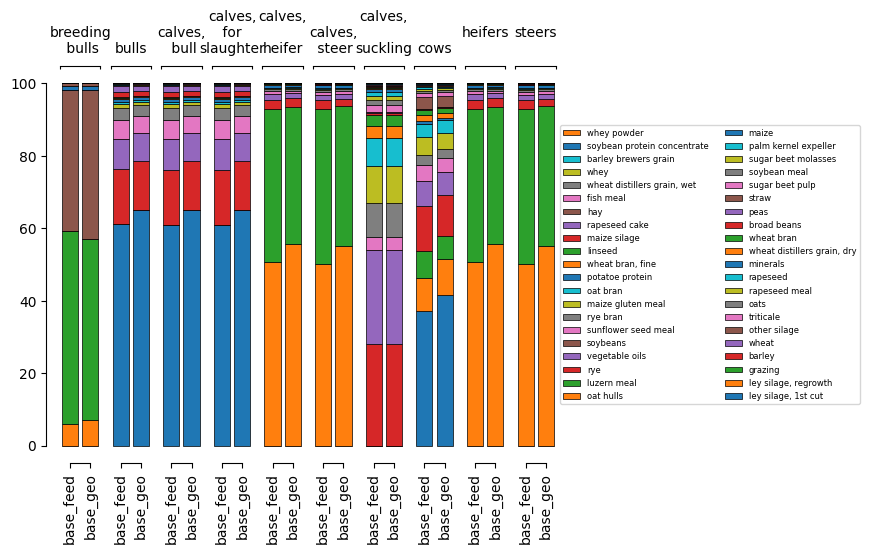

In [134]:
rations = (
    session.get_attr('a','feed.consumption',['species','breed','prod_system','sub_system','animal','feed'])
    .stack(['species','breed','prod_system','sub_system','animal'])
    .fillna(0).div(
        session.get_attr('a','heads',['species','breed','prod_system','sub_system','animal'])
        .stack(['species','breed','prod_system','sub_system','animal']),
        axis = 0
    )
    .stack().droplevel('year').unstack(['scn'])
    .groupby(['species','breed','prod_system','sub_system','animal']).apply(lambda x: x/x.sum()*100)
    .droplevel([0,1,2,3,4])
    .stack().unstack('feed')
)

ax,_ = cm.plot.bar(
    rations.loc[('cattle','dairy','conventional','ley based')],
    group_levels='animal',
    sort_categories=True
)
ax.legend(ncol=2, reverse=True, fontsize=6,
          loc='center left', bbox_to_anchor=(1, 0.5))

In [66]:
rations

feed                                                                                       grazing  \
animal         species breed                       sub_system  animal         scn                    
boars          pigs    none                        none        boars          base_feed   0.000000   
                                                                              base_geo    0.000000   
breeding bulls cattle  beef                        ley based   breeding bulls base_feed  53.103196   
                                                                              base_geo   50.052482   
                                                   maize based breeding bulls base_feed  53.103196   
...                                                                                            ...   
young horses   horses  ponies and Icelandic horses none        young horses   base_geo   30.666667   
                       riding horses               none        young horses   base_feed  36.104036   
                                                                              base_geo   31.666667   
                       trotters and racehorses     none        young horses   base_feed  33.156455   
                                                                              base_geo   29.333333   

feed                                                                                     ley silage, regrowth  \
animal         species breed                       sub_system  animal         scn                               
boars          pigs    none                        none        boars          base_feed              0.000000   
                                                                              base_geo               0.000000   
breeding bulls cattle  beef                        ley based   breeding bulls base_feed              6.102969   
                                                                              base_geo               7.017813   
                                                   maize based breeding bulls base_feed              6.102969   
...                                                                                                       ...   
young horses   horses  ponies and Icelandic horses none        young horses   base_geo               0.000000   
                       riding horses               none        young horses   base_feed              0.000000   
                                                                              base_geo               0.000000   
                       trotters and racehorses     none        young horses   base_feed              0.000000   
                                                                              base_geo               0.000000   

feed                                                                                     minerals  \
animal         species breed                       sub_system  animal         scn                   
boars          pigs    none                        none        boars          base_feed  0.000000   
                                                                              base_geo   0.000000   
breeding bulls cattle  beef                        ley based   breeding bulls base_feed  1.130874   
                                                                              base_geo   1.065907   
                                                   maize based breeding bulls base_feed  1.130874   
...                                                                                           ...   
young horses   horses  ponies and Icelandic horses none        young horses   base_geo   0.298453   
                       riding horses               none        young horses   base_feed  0.212672   
                                                                              base_geo   0.186533   
                       trotters and racehorses     none        young horses   base_feed  0.5

In [79]:
pd.concat([
    session.get_attr('c','area','crop').loc[:,'Ley for grazing'],
    session.get_attr('r','x0_crops','crop').loc[:,'Ley for grazing']
])

scn        year
base_feed  2020    337809.284033
base_geo   2020    309243.856482
base_feed  2020    243941.736682
base_geo   2020    243941.736682
Name: Ley for grazing, dtype: float64

In [80]:
pd.concat([
    session.get_attr('c','area','crop').loc[:,'Semi-natural pastures'],
    session.get_attr('r','x0_crops','crop').loc[:,'Semi-natural pastures']
])

scn        year
base_feed  2020    377300.191821
base_geo   2020    373425.650649
base_feed  2020    370156.346072
base_geo   2020    370156.346072
Name: Semi-natural pastures, dtype: float64

In [26]:
rations#.loc[('cattle','dairy','cows')]

scn                                                                                    base_feed  \
species breed animal         species breed animal         feed                                     
cattle  beef  breeding bulls cattle  beef  breeding bulls grazing                      53.103196   
                                                          ley silage, regrowth          6.102969   
                                                          minerals                      1.130874   
                                                          other silage                 39.026876   
                                                          straw                         0.636085   
...                                                                                          ...   
sheep   none  rams           sheep   none  rams           wheat distillers grain, wet   0.000000   
                                                          whey                          0.000000   
                                                          barley brewers grain          0.000000   
                                                          soybean protein concentrate   0.000023   
                                                          whey powder                   0.000000   

scn                                                                                     base_geo  
species breed animal         species breed animal         feed                                    
cattle  beef  breeding bulls cattle  beef  breeding bulls grazing                      50.052482  
                                                          ley silage, regrowth          7.017813  
                                                          minerals                      1.065907  
                                                          other silage                 41.192418  
                                                          straw                         0.671380  
...                                                                                          ...  
sheep   none  rams           sheep   none  rams           wheat distillers grain, wet   0.000000  
                                                          whey                          0.000000  
                                                          barley brewers grain          0.000000  
                                                          soybean protein concentrate   0.000022  
                                                          whey powder                   0.000000  

[2184 rows x 2 columns]

In [7]:
d = session.get_attr('a', 'feed.consumption',['species','feed']).stack('feed').fillna(0)
((d.loc['base_feed'] - d.loc['base_geo'])/d.loc['base_geo'] * 100).fillna(0).style.format(precision=2)

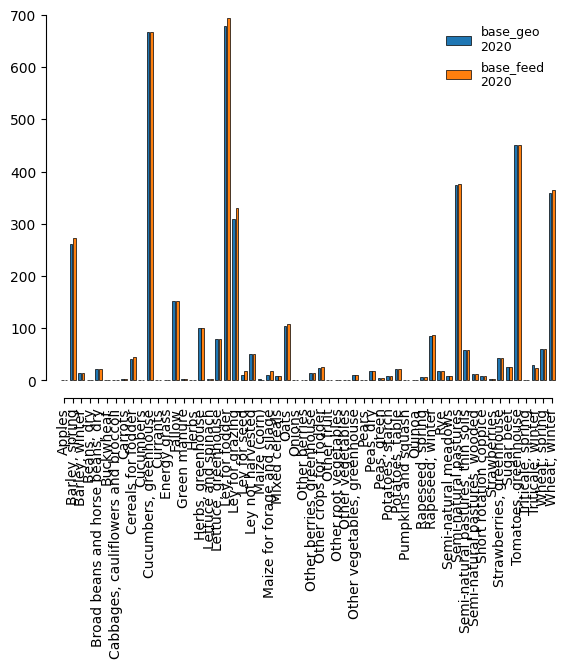

crop
Apples                                  0.06
Barley, spring                          4.36
Barley, winter                         10.23
Beans, dry                             -0.26
Broad beans and horse beans, dry        3.06
Buckwheat                             -24.98
Cabbages, cauliflowers and broccoli    -0.12
Carrots                                -0.03
Cereals for fodder                      6.46
Cucumbers                               0.01
Cucumbers, greenhouse                  -0.00
Currants                                0.26
Energy grass                           -0.21
Fallow                                 -0.17
Green manure                           -0.35
Herbs                                  -0.59
Herbs, greenhouse                      -0.00
Lettuce and spinach                    -0.02
Lettuce, greenhouse                     0.00
Ley for fodder                          2.22
Ley for grazing                         6.51
Ley for seed                           73.65
Ley n

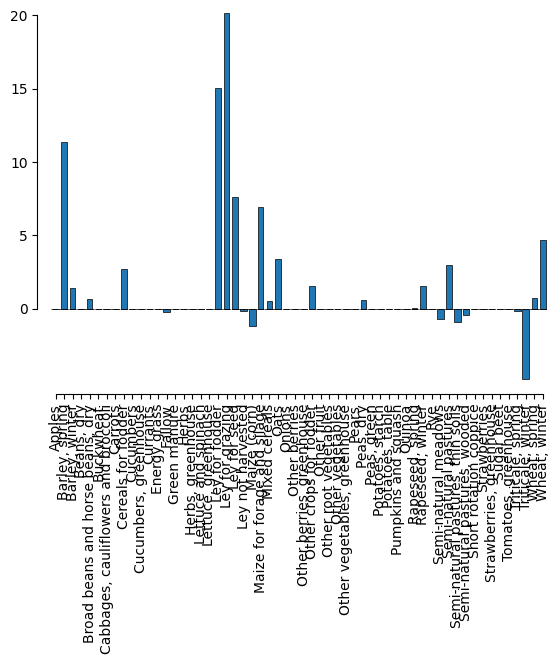

In [80]:
d = pd.concat([
    session.get_attr('g','x_crops','crop').iloc[0],
    session.get_attr('f','x_crops','crop').iloc[0]
], axis=1) / 1_000

fig,ax = cm.plot.bar(
    d,
    stacked=False
)
plt.show()

fig,ax = cm.plot.bar(
    d.iloc[:,1] - d.iloc[:,0],
    stacked=False
)

display(((d.iloc[:,1] - d.iloc[:,0]) / d.iloc[:,0] * 100).round(2))

(<Axes: >, [<Axes: label='inset_axes'>])

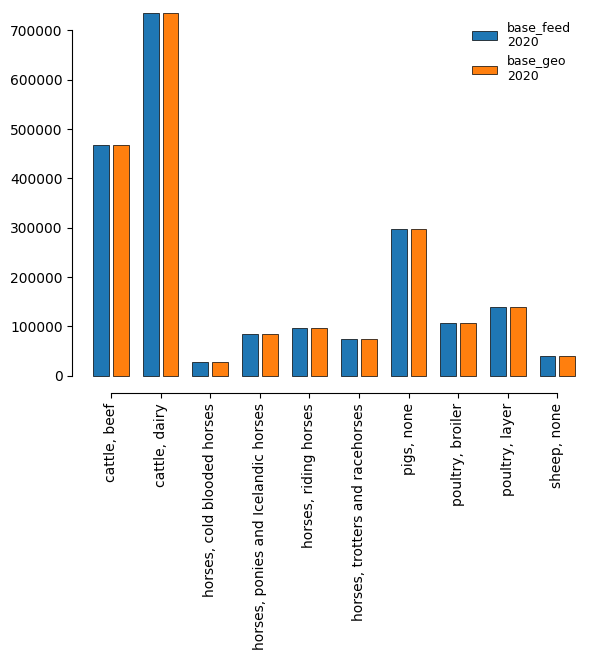

In [68]:
d = cm.impact.get_LSU(session, ['species','breed']).T

cm.plot.bar(
    d,
    stacked=False
)